In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import itertools


from matplotlib import pyplot as plt
from scipy import stats
from tqdm import tqdm
import matplotlib as mpl

from scripts.utils import *
from census import Census
from scripts.census_preprocessing import *
from scripts.cdc_places_preprocessing import *
from scripts.heat_impacts_preprocessing import *
from scripts.analysis import *

nyc_counties = [36005, 36047, 36061, 36081, 36085]

# set to false  to cache data
load_acs_data = False
load_dec_data = False
load_cdc_places_data = False
load_hvi = False
print_all_nri = False
load_nri = False
load_impacts = False

rank_method = "average"  # min, average is alternative
correlation_method = "spearman"  # alternatives are pearson or kendall

# parameters for spatial joins
spatial_join_method = (
    "spatial_overlap"  # alternatives: centroid, representative_point, spatial_overlap
)

In [2]:
# Set up defaults for plotting
markers = ["D", "^", "o"]

# Data Setup and Cleaning

## Load geospatial data

In [3]:
# census tract to nta crosswalk
# set all crs to EPSG:2263 ("NAD83 / New York Long Island (ftUS)")
nyc_open_data_path = (
    "https://data.cityofnewyork.us/resource"  # default path for accessing open data
)
nta_geo, zcta_geo, zcta_2010_geo, tract_geo, boros_geo = load_geospatial(
    nyc_open_data_path, nyc_counties
)
nyc_modzcta = load_modzcta(nyc_open_data_path)
nta_xwalk = load_nta_xwalk(nyc_open_data_path, tract_geo)

------------------------
Loading NTA data
There are 262 unique neighborhoods
------------------------
Loading 2020 and 2010 ZCTA data
Number of unique ZCTAs 215
There are 214 unique ZCTAs in 2020
There are 214 unique ZCTAs in 2010
------------------------
Loading NYC Census Tracts
There are 2325 unique tracts
------------------------
Loading NYC Boroughs
There are 5 unique boroughs
------------------------
Loading MODZCTA data from DOHMH
There are 178 unique MODZCTAs
There are 2 unmerged tracts: 36047990100, 36081990100
There are 2325 unique tracts (for all NTAs)


## Load HVI data

In [4]:
df_hvi_zcta, df_hvi_nta = load_hvi_data(
    nyc_open_data_path, zcta_geo, nta_geo, load_data=load_hvi
)

------------------------
Loading HVI (ZCTA) data
There are 184 unique ZCTAs in the data
------------------------
Loading HVI (NTA) data
Data size: (197, 14)
There are 197 unique NTAs in the data


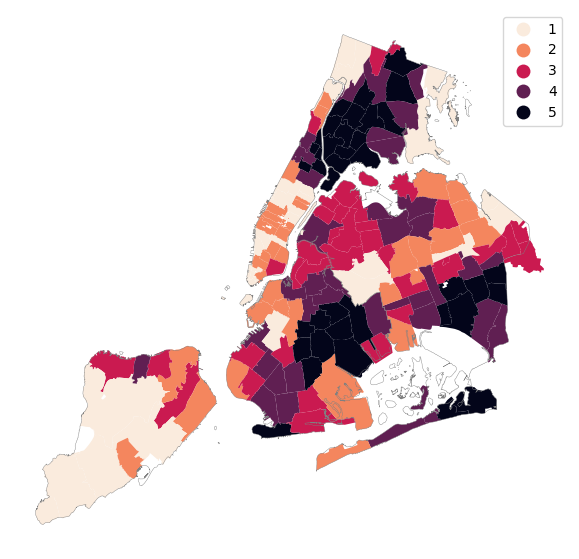

In [5]:
df_hvi_zcta["hvi"] = df_hvi_zcta["hvi"].astype(str)
plot_simple_map(
    zcta_geo.merge(df_hvi_zcta), boros_geo, "hvi", "hvi.pdf", categorical=True
)

## Load ACS and Census data (i.e., sociodemographics)

In [6]:
acs_gdf, acs_zcta_gdf, dec_gdf = load_census(
    tract_geo, zcta_geo, load_acs_data=load_acs_data, load_dec_data=load_dec_data
)

Data size: (2325, 183)
Unmerged: 11439, 11249
Data size: (214, 177)
Data size: (2325, 22)


In [7]:
acs_gdf_hvi = clean_acs_hvi(acs_gdf)

Number of values < 0 for median_hhinc is: 86


## Load the National Risk Index Data (NRI)

In [8]:
df_nri = load_nri_data(nyc_counties, download_nri_data=load_nri)

------------------------
Loading NRI data (tract-level)
There are 2324 unique census tracts in the data
Renaming columns and ranking


In [9]:
[x for x in df_nri.columns if "Community" in x]

['Social Vulnerability and Community Resilience Adjusted Expected Annual Loss Rate - National Percentile - Composite',
 'Community Resilience - Score',
 'Community Resilience - Rating',
 'Community Resilience - State Percentile',
 'Community Resilience - Value',
 'Community Risk Factor - Value']

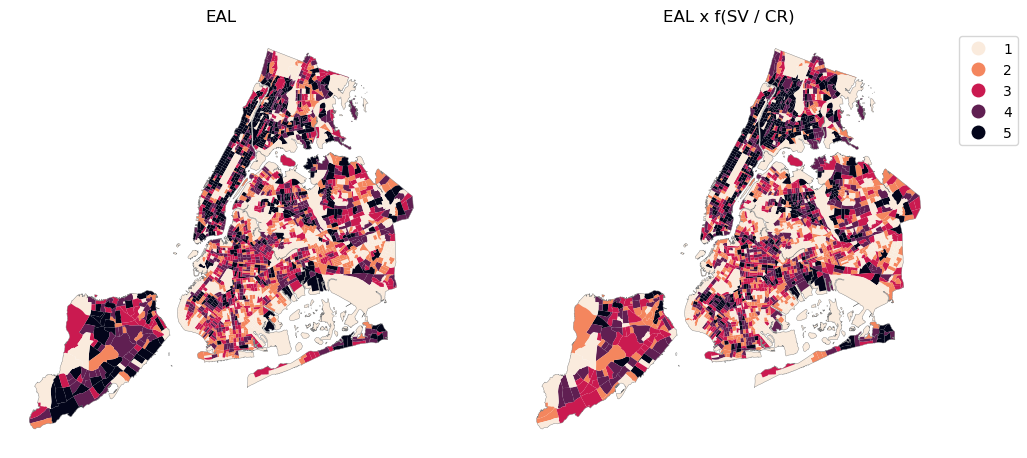

In [10]:
plot_nri(df_nri, tract_geo, boros_geo)

In [11]:
heatwave_vars = [x for x in df_nri.columns if ("Heat" in x) | ("HWAV" in x)]
for var in heatwave_vars:
    if pd.api.types.is_string_dtype(df_nri[var]):
        df_nri[var] = np.select(
            [
                df_nri[var] == "Very Low",
                df_nri[var] == "Relatively Low",
                df_nri[var] == "Relatively Moderate",
                df_nri[var] == "Relatively High",
                df_nri[var] == "Very High",
            ],
            [1, 2, 3, 4, 5],
            0,
        )

if print_all_nri:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    tract_geo[["geoid", "geometry"]].merge(df_nri, on="geoid").plot(
        column=var, cmap="rocket_r", ax=ax, edgecolor="none", legend=True
    )
    boros_geo.plot(ax=ax, facecolor="none", edgecolor="gray", lw=0.3)

    ax.set_title(var)
    ax.axis("off")

    plt.savefig(
        f"./_figures/nri plots/nri_plot_{var}.pdf",
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.show()

### Load URI Data

In [12]:
gdf_uri = load_uri()

In [13]:
if print_all_nri:
    heatwave_vars = [x for x in gdf_uri.columns if "EXHR_" in x]
    for var in heatwave_vars:
        if pd.api.types.is_string_dtype(gdf_uri[var]):
            gdf_uri[var] = np.select(
                [
                    gdf_uri[var] == "Very Low",
                    gdf_uri[var] == "Relatively Low",
                    gdf_uri[var] == "Relatively Moderate",
                    gdf_uri[var] == "Relatively High",
                    gdf_uri[var] == "Very High",
                ],
                [1, 2, 3, 4, 5],
                0,
            )
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        gdf_uri.plot(column=var, cmap="rocket_r", ax=ax, edgecolor="none", legend=True)
        boros_geo.plot(ax=ax, facecolor="none", edgecolor="gray", lw=0.3)

        ax.set_title(var)
        ax.axis("off")

        plt.savefig(
            f"./_figures/uri plots/uri_plot_{var}.pdf",
            bbox_inches="tight",
            pad_inches=0,
            dpi=300,
        )
        plt.show()

## Load CDC Places Data

In [14]:
df_cdc, df_cdc_zcta = load_cdc_places(
    zcta_geo, nyc_counties, year=2024, load_cdc_places_data=load_cdc_places_data
)

------------------------
Loading CDC Places Data


In [15]:
df_cdc_wide = clean_cdc_places(df_cdc, id_var="geoid")

------------------------
Cleaning CDC Places Data
id var = geoid
Number of unique health measures: 13
Conditions:                                                measure   measureid
3                                 Obesity among adults     OBESITY
7                                  Stroke among adults      STROKE
98      No leisure-time physical activity among adults         LPA
104                        Current asthma among adults     CASTHMA
108  Taking medicine to control high blood pressure...       BPMED
112                Coronary heart disease among adults         CHD
115  High cholesterol among adults who have ever be...    HIGHCHOL
117                    Diagnosed diabetes among adults    DIABETES
121  Chronic obstructive pulmonary disease among ad...        COPD
141              Frequent mental distress among adults       MHLTH
212                   High blood pressure among adults      BPHIGH
240            Frequent physical distress among adults       PHLTH
247            

In [16]:
df_cdc_wide_zcta = clean_cdc_places(df_cdc_zcta, id_var="zcta")

------------------------
Cleaning CDC Places Data
id var = zcta
Number of unique health measures: 13
Conditions:                                                   measure   measureid
331222                                Stroke among adults      STROKE
331944                   High blood pressure among adults      BPHIGH
331945  Taking medicine to control high blood pressure...       BPMED
331947                        Current asthma among adults     CASTHMA
331948                Coronary heart disease among adults         CHD
331950                 Cholesterol screening among adults  CHOLSCREEN
331953  Chronic obstructive pulmonary disease among ad...        COPD
331957                    Diagnosed diabetes among adults    DIABETES
331961  High cholesterol among adults who have ever be...    HIGHCHOL
331963     No leisure-time physical activity among adults         LPA
331965              Frequent mental distress among adults       MHLTH
331967                               Obesity am

## Load CDC HHI Data

In [17]:
load_cdc_hhi_from_url()
df_cdc_hhi_geo, df_cdc_hhi_tract = load_and_clean_hhi(
    zcta_2010_geo, tract_geo, join_method=spatial_join_method, rank_method=rank_method
)

------------------------
Loading CDC HHI Data
------------------------
Loading and cleaning CDC HHI Data
Data size: (183, 80)
Producing tract -> ZCTA spatial join (for comparisons)
Tract CRS: EPSG:2263
ZCTA CRS: EPSG:2263
Merged data size: (2323, 80)
Tract data size: (2325, 14)
ZCTA/DPS data size: (183, 80)


/opt/anaconda3/envs/index-env/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


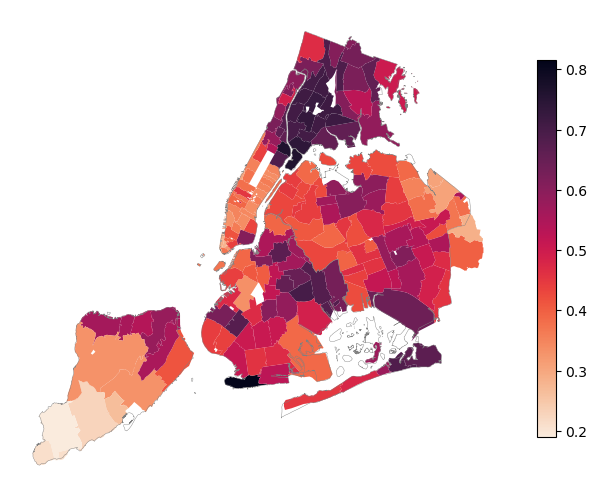

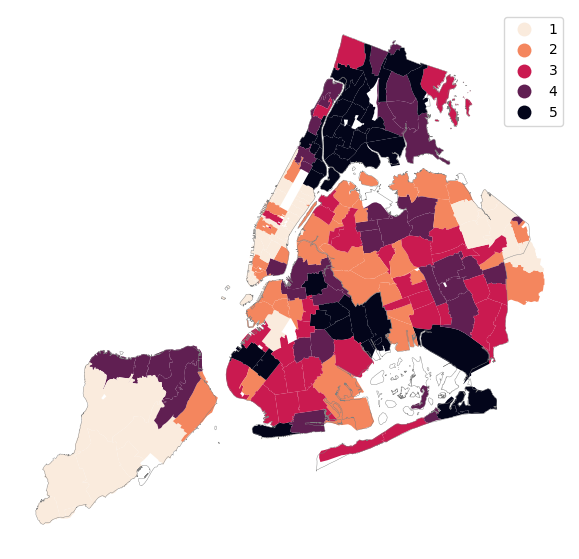

In [18]:
plot_simple_map(df_cdc_hhi_geo, boros_geo, "OVERALL_SCORE", "cdc_hhi_raw.pdf")
plot_simple_map(
    df_cdc_hhi_geo, boros_geo, "OVERALL_SCORE_q5", "cdc_hhi.pdf", categorical=True
)

## Load ECOSTRESS Data

In [19]:
lst_tract = load_ecostress_data(
    "QMD/lst_20200827_vectorized_tract.geojson"
)  # "QMD/lst_20200827_vectorized_tract.geojson") "lst_20250730_vectorized_tract.geojson"
lst_nta = load_ecostress_data(
    "QMD/lst_20200827_vectorized_nta.geojson",
    id_col="NTA2020",  # "lst_20250730_vectorized_nta.geojson", id_col="NTA2020"
).rename(columns={"NTA2020": "nta2020"})

# nta 2025
lst_nta_2025 = load_ecostress_data(
    "lst_20250730_vectorized_nta.geojson", id_col="NTA2020"
).rename(columns={"NTA2020": "nta2020", "_mean_f": "_mean_f_2025"})

------------------------
Loading ECOSTRESS land surface temperature
Data size: (2325, 10)
------------------------
Loading ECOSTRESS land surface temperature
Data size: (262, 10)
------------------------
Loading ECOSTRESS land surface temperature
Data size: (262, 10)


### Comparing different sources of land surface temperature

In [20]:
gdf_uhp_lst_nta = load_ecostress_data(
    "lst_20200709_urban_heat_portal_nta.geojson", id_col="nameAlt"
).rename(columns={"nameAlt": "nta2020", "_mean": "_mean_landsat"})

------------------------
Loading ECOSTRESS land surface temperature
Data size: (262, 10)


Plotting average LST estimates


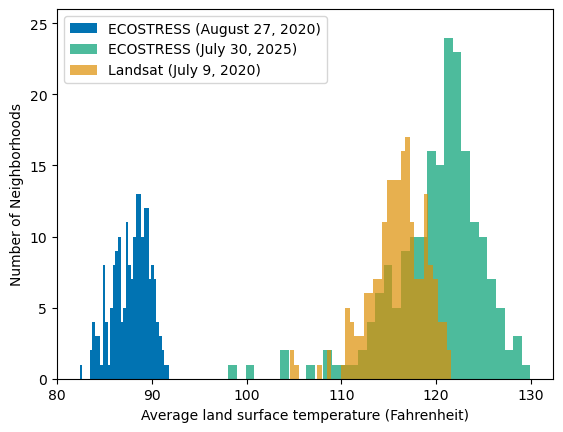

Plotting correlations


,_mean_f,_mean_f_2025,_mean_landsat,SURFACE_TEMP
_mean_f,1.000000,0.473559,0.759663,0.990637
_mean_f_2025,0.473559,1.000000,0.751106,0.436088
_mean_landsat,0.759663,0.751106,1.000000,0.728601
SURFACE_TEMP,0.990637,0.436088,0.728601,1.000000


In [21]:
print("Plotting average LST estimates")
gdf_temperature_data_mgd = (
    lst_nta.merge(
        gdf_uhp_lst_nta[["_mean_landsat", "nta2020"]], on="nta2020", how="left"
    )
    .merge(
        lst_nta_2025,
        on="nta2020",
        how="left",
    )
    .merge(df_hvi_nta, on="nta2020")
)

assert gdf_temperature_data_mgd.shape[0] == 197

plt.hist(
    gdf_temperature_data_mgd["_mean_f"],
    bins=35,
    edgecolor="none",
    label="ECOSTRESS (August 27, 2020)",
    color=colorblind_cmap[0],
)
plt.hist(
    gdf_temperature_data_mgd["_mean_f_2025"],
    bins=35,
    alpha=0.7,
    edgecolor="none",
    label="ECOSTRESS (July 30, 2025)",
    color=colorblind_cmap[2],
)
plt.hist(
    gdf_temperature_data_mgd["_mean_landsat"],
    bins=35,
    alpha=0.7,
    edgecolor="none",
    label="Landsat (July 9, 2020)",
    color=colorblind_cmap[1],
)
plt.legend()
plt.ylabel("Number of Neighborhoods")
plt.xlabel("Average land surface temperature (Fahrenheit)")
plt.ylim(0, 26)
plt.savefig("_figures/comparison_lst.pdf", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

print("Plotting correlations")
gdf_temperature_data_mgd[
    ["_mean_f", "_mean_f_2025", "_mean_landsat", "SURFACE_TEMP"]
].corr(method="pearson")

## Load Vegetation

In [22]:
veg_tract = load_veg_data("zonal_hist.csv", rank_method=rank_method)
veg_nta = load_veg_data(
    "zonal_hist_nta.csv", rank_method=rank_method, id_col="nameAlt"
).rename(columns={"nameAlt": "nta2020"})

------------------------
Loading vegetation data
Data size: (2325, 112)
------------------------
Loading vegetation data
Data size: (262, 14)


## Combine ACS, CDC, and Vegetation at Census Tract Level

In [23]:
print(acs_gdf_hvi.shape)
df_mgd = merge_dfs(acs_gdf_hvi, veg_tract, lst_tract, df_cdc_wide, id_col="geoid")
df_mgd.isna().mean().sort_values(ascending=False).head(10)

(2292, 34)
------------------------
Merging datasets together
ACS data size: 2292
Merged data size: 2292


pct_hh_gt65                0.027487
data_value_STROKE_total    0.026614
data_value_STROKE          0.026614
data_value_BPHIGH          0.026614
data_value_BPMED           0.026614
data_value_CASTHMA         0.026614
data_value_CHD             0.026614
data_value_CHOLSCREEN      0.026614
data_value_COPD            0.026614
data_value_DIABETES        0.026614
dtype: float64

## Produce NTA Summary of Data

In [24]:
health_cdc_cols = [
    x
    for x in df_cdc_wide.columns
    if (("data_value" in x) and ("_total") in x) | ("totalpop" in x.lower())
]
len(health_cdc_cols)

df_nta_summary = produce_nta_summary(
    df_mgd, acs_pop_vars + dec_pop_vars + age_vars + health_cdc_cols
)

------------------------
Producing NTA summary from tract data
Number of NTAs: (246, 38)


In [25]:
df_nta_summary.head()

,nta2020,totalpop,poverty_status_inpoverty,inpoverty_75over_male,inpoverty_75over_female,hh_gt65,total_hh_age,total_over75,black,totalpop_dec,...,data_value_CHD_total,data_value_CHOLSCREEN_total,data_value_COPD_total,data_value_DIABETES_total,data_value_HIGHCHOL_total,data_value_LPA_total,data_value_MHLTH_total,data_value_OBESITY_total,data_value_PHLTH_total,data_value_STROKE_total
0,BK0101,34503.0,3515.0,70.0,440.0,3289.0,16743.0,1980.0,1072.0,38980.0,...,1106.256,30044.462,997.484,1761.407,8287.405485,5454.512,5002.748,7594.658,2736.875,536.625
1,BK0102,59410.0,8830.0,341.0,396.0,3185.0,25874.0,1813.0,3050.0,64444.0,...,1743.960,45612.202,1707.953,3276.107,12069.420156,10655.854,8679.892,12578.069,5016.175,939.563
2,BK0103,45664.0,22987.0,217.0,325.0,2552.0,10563.0,1489.0,1618.0,47703.0,...,2034.030,18855.339,2731.998,2981.908,6569.472637,9452.768,6235.765,7846.088,4947.231,1209.239
3,BK0104,51688.0,13242.0,191.0,535.0,4895.0,22307.0,2981.0,8249.0,52998.0,...,2408.027,38560.873,2359.874,4676.427,11901.202430,13030.339,8076.211,12131.562,6022.299,1409.064
4,BK0201,23874.0,1074.0,25.0,151.0,3035.0,11506.0,1680.0,1248.0,25092.0,...,879.200,19326.911,646.093,1272.493,5948.619054,3066.919,2647.054,4244.242,1597.003,392.246


## Load HVI at NTA Level

In [26]:
df_hvi_analysis = df_hvi_nta.merge(df_nta_summary, on="nta2020", how="left")
df_hvi_analysis = produce_pct(df_hvi_analysis)

print(f"Data size: {df_hvi_analysis.shape}")
df_hvi_analysis, health_cdc_pct_cols = cdc_nta_cleaning(
    df_hvi_analysis, health_cdc_cols
)

health_zscore_cols = [
    x + "_z"
    for x in health_cdc_pct_cols
    if x
    not in [
        "data_value_CHOLSCREEN_pct",
        "data_value_BPMED_pct",
        "data_value_SELFCARE_pct",
        "data_value_MOBILITY_pct",
    ]  #
]

Data size: (197, 58)


In [27]:
len(health_zscore_cols)

11

In [28]:
# merge in lst and vegetation
df_mgd_nta = merge_dfs(df_hvi_analysis, veg_nta, lst_nta, None, id_col="nta2020")

print("\nMissing value %:")
df_mgd_nta.isna().mean().sort_values(ascending=False).head(10)

------------------------
Merging datasets together
ACS data size: 197
Merged data size: 197

Missing value %:


nta2020                   0.0
pct_inpoverty_75over      0.0
data_value_CHD_pct        0.0
data_value_CASTHMA_pct    0.0
data_value_BPMED_pct      0.0
data_value_BPHIGH_pct     0.0
nonwhite_nh_dec_pct       0.0
pct_over_75               0.0
pct_over65                0.0
pct_inpoverty             0.0
dtype: float64

# Analysis

## Visualize all index Tools

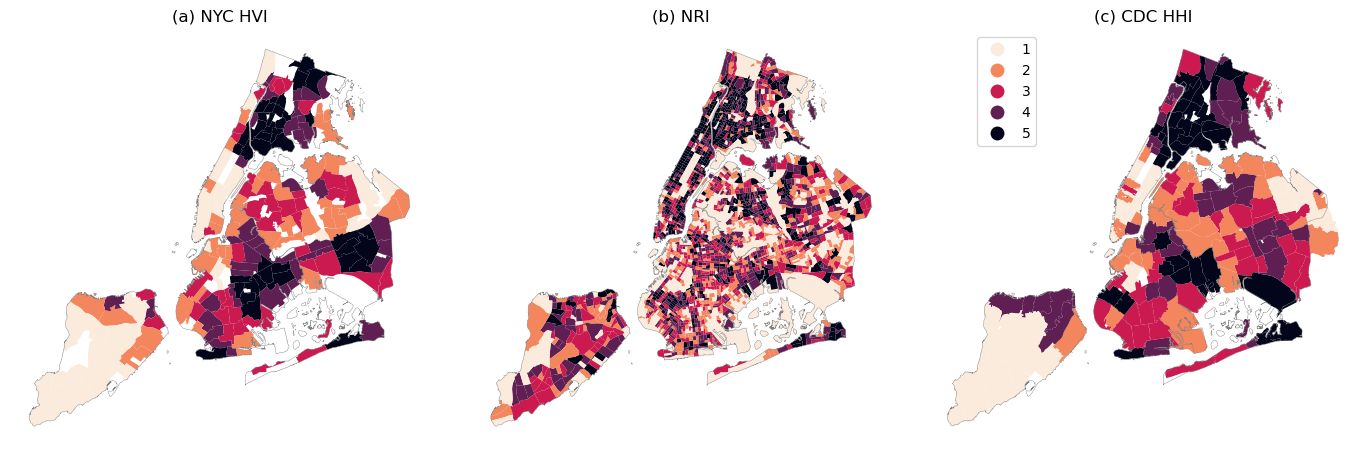

In [29]:
def plot_all_indices(hvi, nri, cdc):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    hvi[["geometry", "nta2020"]].merge(df_hvi_analysis).plot(
        column="HVI_RANK",
        ax=axes[0],
        cmap="rocket_r",
        legend=False,
        edgecolor="none",
    )
    nri.plot(
        column="HWAV_EALTxSVIxRESL_q5",
        cmap="rocket_r",
        ax=axes[1],
        legend=False,
        edgecolor="none",
    )

    axes[1].set_title("(b) NRI")
    cdc["OVERALL_SCORE_q5"] = cdc["OVERALL_SCORE_q5"].astype(str).str.replace(".0", "")
    cdc.plot(
        column="OVERALL_SCORE_q5",
        ax=axes[2],
        cmap="rocket_r",
        edgecolor="none",
        legend=True,
        legend_kwds={"loc": "upper left", "bbox_to_anchor": (0.1, 1)},
    )
    axes[0].set_axis_off()
    axes[1].set_axis_off()
    axes[2].set_axis_off()

    axes[0].set_title("(a) NYC HVI")
    axes[2].set_title("(c) CDC HHI")

    boros_geo.plot(ax=axes[0], facecolor="none", edgecolor="gray", lw=0.3)
    boros_geo.plot(ax=axes[1], facecolor="none", edgecolor="gray", lw=0.3)
    boros_geo.plot(ax=axes[2], facecolor="none", edgecolor="gray", lw=0.3)
    plt.savefig(
        "./_figures/all_index_tools.pdf", bbox_inches="tight", pad_inches=0, dpi=300
    )
    plt.tight_layout()
    plt.show()


plot_all_indices(nta_geo, tract_geo.merge(df_nri), df_cdc_hhi_geo)

## HVI Replication

In [30]:
vars_hvi = [
    "SURFACE_TEMP",
    "MEDIAN_INCOME",
    "GREENSPACE",
    "PCT_HOUSEHOLDS_AC",
    "PCT_BLACK_POP",
    "pct_hh_gt65",
    "pct_inpoverty_75over",
    "pct_over_75",
    "pct_inpoverty",
    "pct_over65",
    "nonwhite_nh_dec_pct",
]

df_hvi_analysis = df_hvi_analysis.copy()

In [31]:
# ensure in all the columns, we are only keeping are z-scores
cols_to_keep = [
    x + "_z" for x in vars_hvi + health_cdc_pct_cols + ["max_cdc_health_vars"]
] + ["HVI_RANK", "nta2020"]

df_alt_specifications = standardize_values(
    df_hvi_analysis,
    vars_hvi + health_cdc_pct_cols + ["max_cdc_health_vars"],
    rank_method=rank_method,
)[cols_to_keep].copy()

In [32]:
# produce all of the alternatiive specifications
alt_specifications = [
    "HVI_raw",
    "HVI_env",
    "HVI_age",
    "HVI_health",
    "HVI_all",
    "HVI_health_alt",
    "HVI_all_alt",
    "HVI_min",
]
df_alt_specifications = produce_all_specifications(
    df_alt_specifications, health_zscore_cols
)

------------------------
Producing all specifications
Reproducing original
Producing environmental only
Producing age and poverty prioritized
Producing health comorbidities added
Producing all (combined)
Producing minority status instead of race
Producing comorbidities (with average)
Producing all (with averaged comorbidities)


In [33]:
# ranking alt specifications, merge to gdf
gdf_alt_specifications = rank_all_specifications(
    df_alt_specifications.copy(), nta_geo, alt_specifications, rank_method
)

------------------------
Ranking all specifications
Producing alt specification for HVI_raw
Producing alt specification for HVI_env
Producing alt specification for HVI_age
Producing alt specification for HVI_health
Producing alt specification for HVI_all
Producing alt specification for HVI_health_alt
Producing alt specification for HVI_all_alt
Producing alt specification for HVI_min

Comparing differences between original and replicated HVI score
HVI_RANK  HVI_raw_q5
5         5.0           40
4         4.0           39
3         3.0           39
2         2.0           38
1         1.0           37
2         1.0            2
3         2.0            1
4         3.0            1
Name: count, dtype: int64
Accuracy of replicated HVI (5-pt scale): 98.0%


## Correlation Analyses

In [34]:
produce_correlations(gdf_alt_specifications, alt_specifications, "pearson")

------------------------
Correlation using pearson
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw & HVI_env & HVI_age & HVI_health & HVI_all & HVI_health_alt & HVI_all_alt & HVI_min \\
\midrule
HVI_raw & 1.0 & 0.674 & 0.868 & 0.855 & 0.836 & 0.948 & 0.91 & 0.964 \\
HVI_env & 0.674 & 1.0 & 0.693 & 0.4 & 0.38 & 0.642 & 0.552 & 0.692 \\
HVI_age & 0.868 & 0.693 & 1.0 & 0.792 & 0.805 & 0.803 & 0.892 & 0.869 \\
HVI_health & 0.855 & 0.4 & 0.792 & 1.0 & 0.997 & 0.777 & 0.85 & 0.842 \\
HVI_all & 0.836 & 0.38 & 0.805 & 0.997 & 1.0 & 0.76 & 0.856 & 0.825 \\
HVI_health_alt & 0.948 & 0.642 & 0.803 & 0.777 & 0.76 & 1.0 & 0.946 & 0.877 \\
HVI_all_alt & 0.91 & 0.552 & 0.892 & 0.85 & 0.856 & 0.946 & 1.0 & 0.853 \\
HVI_min & 0.964 & 0.692 & 0.869 & 0.842 & 0.825 & 0.877 & 0.853 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw,HVI_env,HVI_age,HVI_health,HVI_all,HVI_health_alt,HVI_all_alt,HVI_min
HVI_raw,1.000000,0.673926,0.868033,0.854536,0.836378,0.947915,0.910482,0.964108
HVI_env,0.673926,1.000000,0.692519,0.399903,0.379800,0.641824,0.552403,0.691926
HVI_age,0.868033,0.692519,1.000000,0.791919,0.804735,0.803199,0.891671,0.868506
HVI_health,0.854536,0.399903,0.791919,1.000000,0.997240,0.777045,0.850093,0.841852
HVI_all,0.836378,0.379800,0.804735,0.997240,1.000000,0.760353,0.856183,0.825217
HVI_health_alt,0.947915,0.641824,0.803199,0.777045,0.760353,1.000000,0.945902,0.876655
HVI_all_alt,0.910482,0.552403,0.891671,0.850093,0.856183,0.945902,1.000000,0.852563
HVI_min,0.964108,0.691926,0.868506,0.841852,0.825217,0.876655,0.852563,1.000000


In [35]:
rank_vars = [x + "_rank" for x in alt_specifications]
corr_rankings = produce_correlations(
    gdf_alt_specifications, rank_vars, correlation_method
)
corr_rankings

------------------------
Correlation using spearman
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw_rank & HVI_env_rank & HVI_age_rank & HVI_health_rank & HVI_all_rank & HVI_health_alt_rank & HVI_all_alt_rank & HVI_min_rank \\
\midrule
HVI_raw_rank & 1.0 & 0.643 & 0.869 & 0.885 & 0.87 & 0.95 & 0.918 & 0.957 \\
HVI_env_rank & 0.643 & 1.0 & 0.673 & 0.432 & 0.414 & 0.62 & 0.534 & 0.667 \\
HVI_age_rank & 0.869 & 0.673 & 1.0 & 0.817 & 0.831 & 0.819 & 0.9 & 0.866 \\
HVI_health_rank & 0.885 & 0.432 & 0.817 & 1.0 & 0.996 & 0.812 & 0.871 & 0.859 \\
HVI_all_rank & 0.87 & 0.414 & 0.831 & 0.996 & 1.0 & 0.799 & 0.879 & 0.844 \\
HVI_health_alt_rank & 0.95 & 0.62 & 0.819 & 0.812 & 0.799 & 1.0 & 0.948 & 0.886 \\
HVI_all_alt_rank & 0.918 & 0.534 & 0.9 & 0.871 & 0.879 & 0.948 & 1.0 & 0.858 \\
HVI_min_rank & 0.957 & 0.667 & 0.866 & 0.859 & 0.844 & 0.886 & 0.858 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_rank,HVI_env_rank,HVI_age_rank,HVI_health_rank,HVI_all_rank,HVI_health_alt_rank,HVI_all_alt_rank,HVI_min_rank
HVI_raw_rank,1.000000,0.642921,0.868778,0.885190,0.870211,0.949871,0.917510,0.956539
HVI_env_rank,0.642921,1.000000,0.673215,0.431863,0.413828,0.620313,0.534145,0.667158
HVI_age_rank,0.868778,0.673215,1.000000,0.816611,0.831068,0.818579,0.899632,0.865752
HVI_health_rank,0.885190,0.431863,0.816611,1.000000,0.996333,0.812384,0.871274,0.858612
HVI_all_rank,0.870211,0.413828,0.831068,0.996333,1.000000,0.799246,0.879461,0.844261
HVI_health_alt_rank,0.949871,0.620313,0.818579,0.812384,0.799246,1.000000,0.948345,0.885746
HVI_all_alt_rank,0.917510,0.534145,0.899632,0.871274,0.879461,0.948345,1.000000,0.857653
HVI_min_rank,0.956539,0.667158,0.865752,0.858612,0.844261,0.885746,0.857653,1.000000


In [36]:
q5_vars = [x + "_q5" for x in alt_specifications]
corr_quintiles = produce_correlations(
    gdf_alt_specifications, q5_vars, correlation_method
)
corr_quintiles

------------------------
Correlation using spearman
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw_q5 & HVI_env_q5 & HVI_age_q5 & HVI_health_q5 & HVI_all_q5 & HVI_health_alt_q5 & HVI_all_alt_q5 & HVI_min_q5 \\
\midrule
HVI_raw_q5 & 1.0 & 0.596 & 0.843 & 0.858 & 0.848 & 0.909 & 0.886 & 0.929 \\
HVI_env_q5 & 0.596 & 1.0 & 0.631 & 0.416 & 0.408 & 0.571 & 0.502 & 0.644 \\
HVI_age_q5 & 0.843 & 0.631 & 1.0 & 0.774 & 0.795 & 0.774 & 0.866 & 0.82 \\
HVI_health_q5 & 0.858 & 0.416 & 0.774 & 1.0 & 0.975 & 0.784 & 0.83 & 0.812 \\
HVI_all_q5 & 0.848 & 0.408 & 0.795 & 0.975 & 1.0 & 0.777 & 0.843 & 0.802 \\
HVI_health_alt_q5 & 0.909 & 0.571 & 0.774 & 0.784 & 0.777 & 1.0 & 0.919 & 0.847 \\
HVI_all_alt_q5 & 0.886 & 0.502 & 0.866 & 0.83 & 0.843 & 0.919 & 1.0 & 0.82 \\
HVI_min_q5 & 0.929 & 0.644 & 0.82 & 0.812 & 0.802 & 0.847 & 0.82 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_q5,HVI_env_q5,HVI_age_q5,HVI_health_q5,HVI_all_q5,HVI_health_alt_q5,HVI_all_alt_q5,HVI_min_q5
HVI_raw_q5,1.000000,0.595803,0.842704,0.858202,0.847998,0.908677,0.885975,0.928764
HVI_env_q5,0.595803,1.000000,0.631131,0.415936,0.408283,0.570678,0.501994,0.644465
HVI_age_q5,0.842704,0.631131,1.000000,0.774437,0.794781,0.774052,0.865566,0.819809
HVI_health_q5,0.858202,0.415936,0.774437,1.000000,0.974746,0.784320,0.830206,0.812380
HVI_all_q5,0.847998,0.408283,0.794781,0.974746,1.000000,0.776571,0.842736,0.802112
HVI_health_alt_q5,0.908677,0.570678,0.774052,0.784320,0.776571,1.000000,0.918849,0.847453
HVI_all_alt_q5,0.885975,0.501994,0.865566,0.830206,0.842736,0.918849,1.000000,0.819648
HVI_min_q5,0.928764,0.644465,0.819809,0.812380,0.802112,0.847453,0.819648,1.000000


### Sensitivity check: effect of choosing different health comorbidities

In [37]:
corr_vals, q5_corr_vals, health_zscore_cols_combinations = (
    health_specification_correlations(
        gdf_alt_specifications, health_zscore_cols, rank_method, "kendall"
    )
)
print("Correlation stats for rankings")
print_health_cols_corr(corr_vals)

print("\nCorrelation stats for quintile rankings")
print_health_cols_corr(q5_corr_vals)

100%|██████████| 2047/2047 [00:05<00:00, 356.63it/s]

Correlation stats for rankings
Average value: 0.7551
Minimum: 0.662
Maximum: 0.9067
Median and IQR: 0.7526 (0.7288-0.7783)

Correlation stats for quintile rankings
Average value: 0.811
Minimum: 0.7329
Maximum: 0.9363
Median and IQR: 0.8119 (0.7918-0.831)


In [38]:
health_zscore_cols

['data_value_BPHIGH_pct_z',
 'data_value_CASTHMA_pct_z',
 'data_value_CHD_pct_z',
 'data_value_COPD_pct_z',
 'data_value_DIABETES_pct_z',
 'data_value_HIGHCHOL_pct_z',
 'data_value_LPA_pct_z',
 'data_value_MHLTH_pct_z',
 'data_value_OBESITY_pct_z',
 'data_value_PHLTH_pct_z',
 'data_value_STROKE_pct_z']

In [39]:
# get top 5 lowest correlations
[(health_zscore_cols_combinations[i], corr_vals[i]) for i in np.argsort(corr_vals)[:5]]

[(('data_value_BPHIGH_pct_z',
   'data_value_CHD_pct_z',
   'data_value_COPD_pct_z',
   'data_value_DIABETES_pct_z',
   'data_value_HIGHCHOL_pct_z',
   'data_value_LPA_pct_z',
   'data_value_PHLTH_pct_z',
   'data_value_STROKE_pct_z'),
  np.float64(0.6619703719051072)),
 (('data_value_BPHIGH_pct_z',
   'data_value_CHD_pct_z',
   'data_value_COPD_pct_z',
   'data_value_DIABETES_pct_z',
   'data_value_HIGHCHOL_pct_z',
   'data_value_LPA_pct_z',
   'data_value_STROKE_pct_z'),
  np.float64(0.6638350771780793)),
 (('data_value_BPHIGH_pct_z',
   'data_value_CHD_pct_z',
   'data_value_COPD_pct_z',
   'data_value_DIABETES_pct_z',
   'data_value_HIGHCHOL_pct_z',
   'data_value_STROKE_pct_z'),
  np.float64(0.6679788666735729)),
 (('data_value_BPHIGH_pct_z',
   'data_value_CHD_pct_z',
   'data_value_COPD_pct_z',
   'data_value_DIABETES_pct_z',
   'data_value_HIGHCHOL_pct_z',
   'data_value_PHLTH_pct_z',
   'data_value_STROKE_pct_z'),
  np.float64(0.6687040298352843)),
 (('data_value_BPHIGH_pct_z'

In [40]:
# and top 5 highest
[
    (health_zscore_cols_combinations[i], corr_vals[i])
    for i in np.argsort(corr_vals)[-10:]
]

[(('data_value_CASTHMA_pct_z', 'data_value_LPA_pct_z'),
  np.float64(0.8811768362167202)),
 (('data_value_BPHIGH_pct_z',), np.float64(0.8827307572775303)),
 (('data_value_COPD_pct_z',), np.float64(0.8886356573086086)),
 (('data_value_DIABETES_pct_z',), np.float64(0.8901895783694187)),
 (('data_value_LPA_pct_z',), np.float64(0.8969232362995959)),
 (('data_value_MHLTH_pct_z',), np.float64(0.898787941572568)),
 (('data_value_OBESITY_pct_z',), np.float64(0.8993059152595048)),
 (('data_value_CASTHMA_pct_z',), np.float64(0.9022065679063503)),
 (('data_value_PHLTH_pct_z',), np.float64(0.9061431679270692)),
 (('data_value_STROKE_pct_z',), np.float64(0.9066611416140059))]

Text(0.5, 0, 'Correlation coefficient')

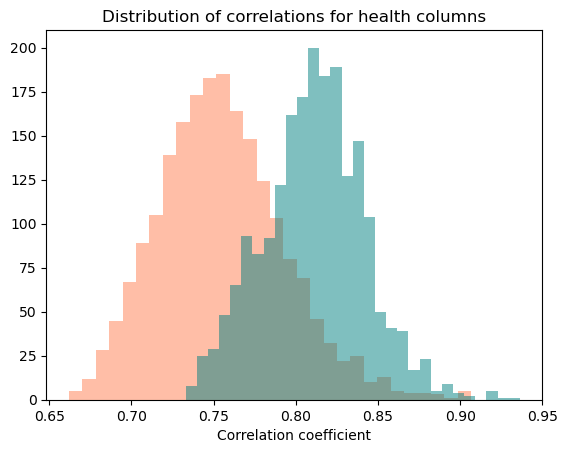

In [41]:
# plot the distribution of correlations
plt.hist(corr_vals, color="coral", alpha=0.5, bins=30)
plt.hist(q5_corr_vals, color="teal", alpha=0.5, bins=30)
plt.title("Distribution of correlations for health columns")
plt.xlabel("Correlation coefficient")

In [42]:
# check specific orrelation with versions from CDC HHI
rank_corr, q5_corr = test_sensitivity_health_specification(
    gdf_alt_specifications,
    (
        "data_value_CHD_pct_z",
        "data_value_OBESITY_pct_z",
        "data_value_DIABETES_pct_z",
        "data_value_COPD_pct_z",
        "data_value_CASTHMA_pct_z",
        "data_value_MHLTH_pct_z",
    ),
    rank_method,
    correlation_method,
)
print(f"Rank correlation with CDC HHI health vars: {rank_corr}")
print(f"Quintile correlation with CDC HHI health vars: {q5_corr}")

Rank correlation with CDC HHI health vars: 0.9260270790365062
Quintile correlation with CDC HHI health vars: 0.8961782517846106


In [43]:
agreement_summary = summarize_agreement(gdf_alt_specifications, alt_specifications)

HVI_raw_match           100.000000
HVI_env_match            32.487310
HVI_age_match            55.329949
HVI_health_match         53.299492
HVI_all_match            49.238579
HVI_health_alt_match     69.035533
HVI_all_alt_match        63.451777
HVI_min_match            71.573604
dtype: float64


In [44]:
print(
    pd.concat(
        [
            corr_rankings.iloc[:, 0].reset_index(drop=True),
            corr_quintiles.iloc[:, 0].reset_index(drop=True),
            agreement_summary.reset_index(drop=True),
        ],
        axis=1,
        ignore_index=True,
    )
    .round(3)
    .astype(str)
    .to_latex()
)

\begin{tabular}{llll}
\toprule
 & 0 & 1 & 2 \\
\midrule
0 & 1.0 & 1.0 & 100.0 \\
1 & 0.643 & 0.596 & 32.487 \\
2 & 0.869 & 0.843 & 55.33 \\
3 & 0.885 & 0.858 & 53.299 \\
4 & 0.87 & 0.848 & 49.239 \\
5 & 0.95 & 0.909 & 69.036 \\
6 & 0.918 & 0.886 & 63.452 \\
7 & 0.957 & 0.929 & 71.574 \\
\bottomrule
\end{tabular}



### Compare to URI

In [45]:
# compare the HVI and the URI
uri_vars = [
    "EXHU_PN",
    "EXHE_PXXT",
    "EXHU_SN",
    "EXHE_SXXT",
]  # , "EXHR_PTTTT", "EXHR_STTTT"
# EXHU_PN = Extreme Heat Risk Index Percentile
# EXHU_SN = Extreme Heat Risk Index Score
# EXHE_PXXT = Extreme Heat Expected Loss Percentile
# EXHR_PTTTT = Extreme Heat Resilience Capacity Percentile
gdf_hvi_uri_comp = gdf_alt_specifications.merge(gdf_uri, on="nta2020").copy()
produce_correlations(
    gdf_hvi_uri_comp,
    ["HVI_raw_rank"] + uri_vars[:2] + ["HVI_raw_q5"] + uri_vars[2:],
    correlation_method,
)  # ["HVI_raw", ]

------------------------
Correlation using spearman
\begin{tabular}{lllllll}
\toprule
 & HVI_raw_rank & EXHU_PN & EXHE_PXXT & HVI_raw_q5 & EXHU_SN & EXHE_SXXT \\
\midrule
HVI_raw_rank & 1.0 & 0.623 & 0.155 & 0.98 & 0.581 & 0.122 \\
EXHU_PN & 0.623 & 1.0 & 0.338 & 0.62 & 0.943 & 0.284 \\
EXHE_PXXT & 0.155 & 0.338 & 1.0 & 0.153 & 0.34 & 0.966 \\
HVI_raw_q5 & 0.98 & 0.62 & 0.153 & 1.0 & 0.571 & 0.122 \\
EXHU_SN & 0.581 & 0.943 & 0.34 & 0.571 & 1.0 & 0.293 \\
EXHE_SXXT & 0.122 & 0.284 & 0.966 & 0.122 & 0.293 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_rank,EXHU_PN,EXHE_PXXT,HVI_raw_q5,EXHU_SN,EXHE_SXXT
HVI_raw_rank,1.000000,0.623164,0.155196,0.979799,0.581090,0.121510
EXHU_PN,0.623164,1.000000,0.338395,0.619618,0.942660,0.284330
EXHE_PXXT,0.155196,0.338395,1.000000,0.153263,0.340302,0.965700
HVI_raw_q5,0.979799,0.619618,0.153263,1.000000,0.571238,0.121744
EXHU_SN,0.581090,0.942660,0.340302,0.571238,1.000000,0.293183
EXHE_SXXT,0.121510,0.284330,0.965700,0.121744,0.293183,1.000000


------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: EXHU
Data size: (197, 220)
Plotting EXHU
df temp size: (197, 8)
------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: EXHU
Data size: (197, 220)
Plotting EXHU
df temp size: (197, 8)


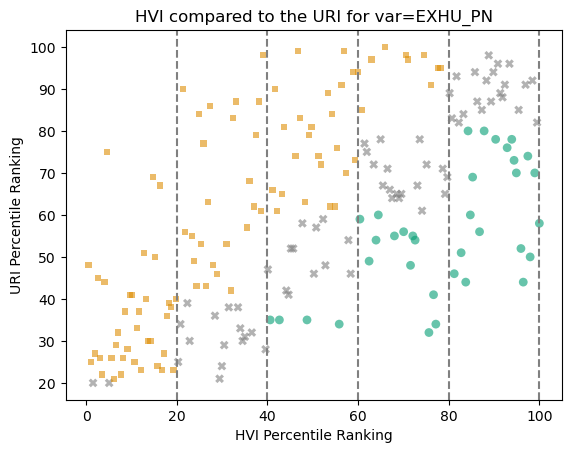

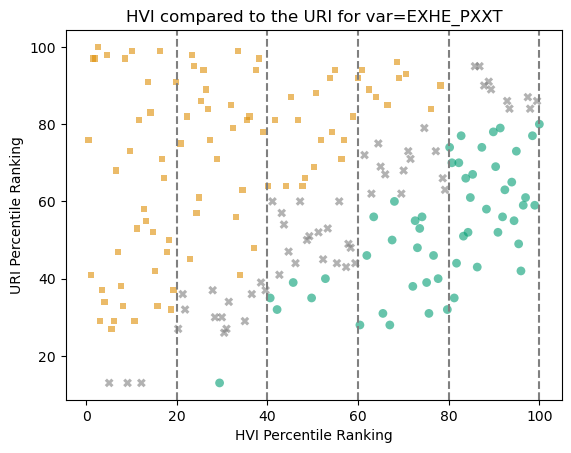

In [46]:
for var in ["EXHU_PN", "EXHE_PXXT"]:
    gdf_hvi_uri_plt = gdf_hvi_uri_comp.copy()
    gdf_hvi_uri_plt["EXHU_q5"] = np.select(
        [
            gdf_hvi_uri_plt[var] <= 20,
            gdf_hvi_uri_plt[var] <= 40,
            gdf_hvi_uri_plt[var] <= 60,
            gdf_hvi_uri_plt[var] <= 80,
            gdf_hvi_uri_plt[var] <= 100,
        ],
        [1, 2, 3, 4, 5],
        np.nan,
    )
    gdf_hvi_uri_plt = prep_for_plot(
        gdf_hvi_uri_plt.rename(columns={var: "EXHU_rank"}),
        ["EXHU"],
        "HVI_raw",
        "nta2020",
    )

    fig, ax = plt.subplots(1, 1)
    ax.axvline(20, color="gray", linestyle="dashed")
    ax.axvline(40, color="gray", linestyle="dashed")
    ax.axvline(60, color="gray", linestyle="dashed")
    ax.axvline(80, color="gray", linestyle="dashed")
    ax.axvline(100, color="gray", linestyle="dashed")
    produce_scatter(gdf_hvi_uri_plt, "HVI_raw", ax)
    ax.set_ylabel("URI Percentile Ranking")
    ax.set_xlabel("HVI Percentile Ranking")
    ax.set_title(f"HVI compared to the URI for var={var}")

### Compare replication to original

In [47]:
# check what's not merging
unmatched_filter = (
    gdf_alt_specifications["HVI_raw_q5"] != gdf_alt_specifications["HVI_RANK"]
)
print(f"Number of NTAs not matching: {unmatched_filter.sum()}")
print(f"Number of NTAs matching: {(unmatched_filter == 0).sum()}")
print(f"Overall accuracy of match: {100*(unmatched_filter == 0).mean().round(4)}%")
gdf_alt_specifications["unmatched"] = np.where(unmatched_filter, 1, 0)

Number of NTAs not matching: 4
Number of NTAs matching: 193
Overall accuracy of match: 97.97%


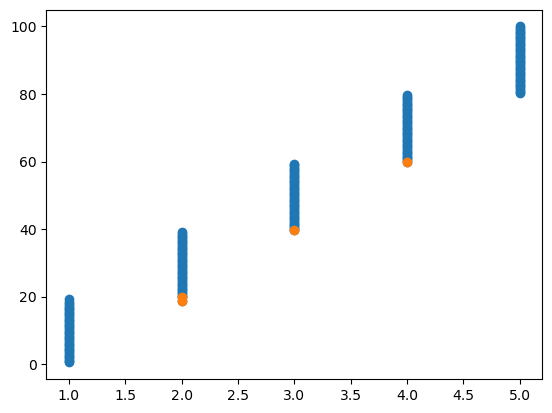

In [48]:
plt.scatter(
    gdf_alt_specifications["HVI_RANK"].astype(float),
    gdf_alt_specifications["HVI_raw_rank"],
    label="HVI original rankings X replicated",
)

plt.scatter(
    gdf_alt_specifications[unmatched_filter]["HVI_RANK"].astype(float),
    gdf_alt_specifications[unmatched_filter]["HVI_raw_rank"],
    label="Rankings do not match",
)
plt.show();

In [49]:
alt_specifications_without_original = [x for x in alt_specifications]

## Produce maps of differences in risk score prioritizations

In [50]:
gdf_alt_increases = compute_risk_increase(
    gdf_alt_specifications, alt_specifications
).copy()

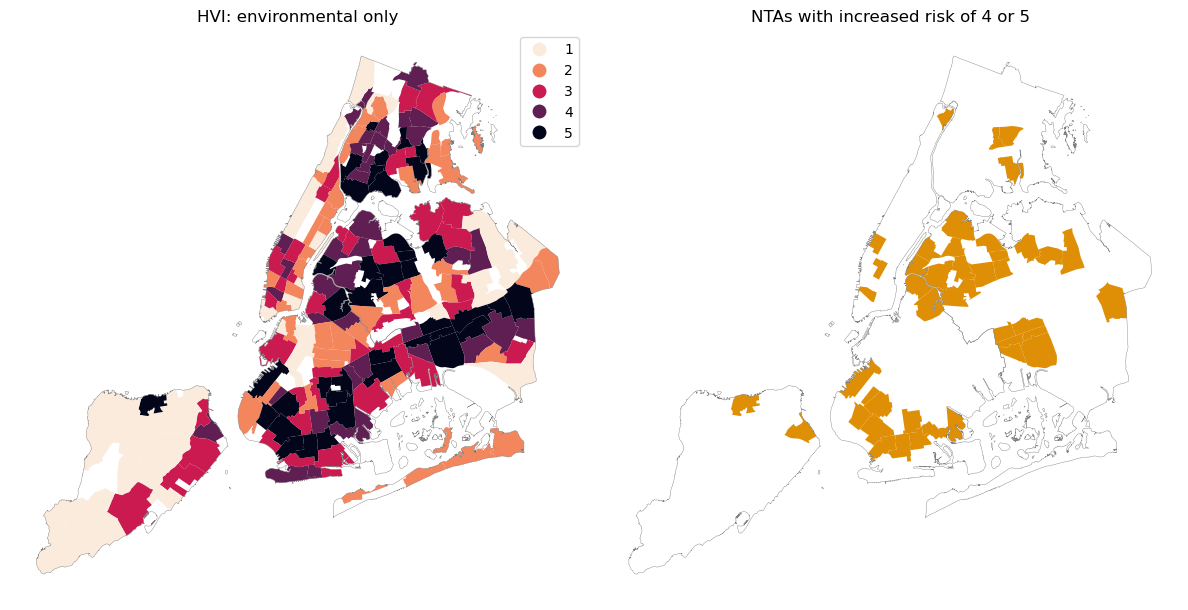

55                        Hunts Point
155               South Richmond Hill
165                           Jamaica
79                 Westchester Square
3                   East Williamsburg
156                Ozone Park (North)
127    Long Island City-Hunters Point
158                  South Ozone Park
14             East New York-New Lots
47             East Flatbush-Farragut
Name: ntaname, dtype: str


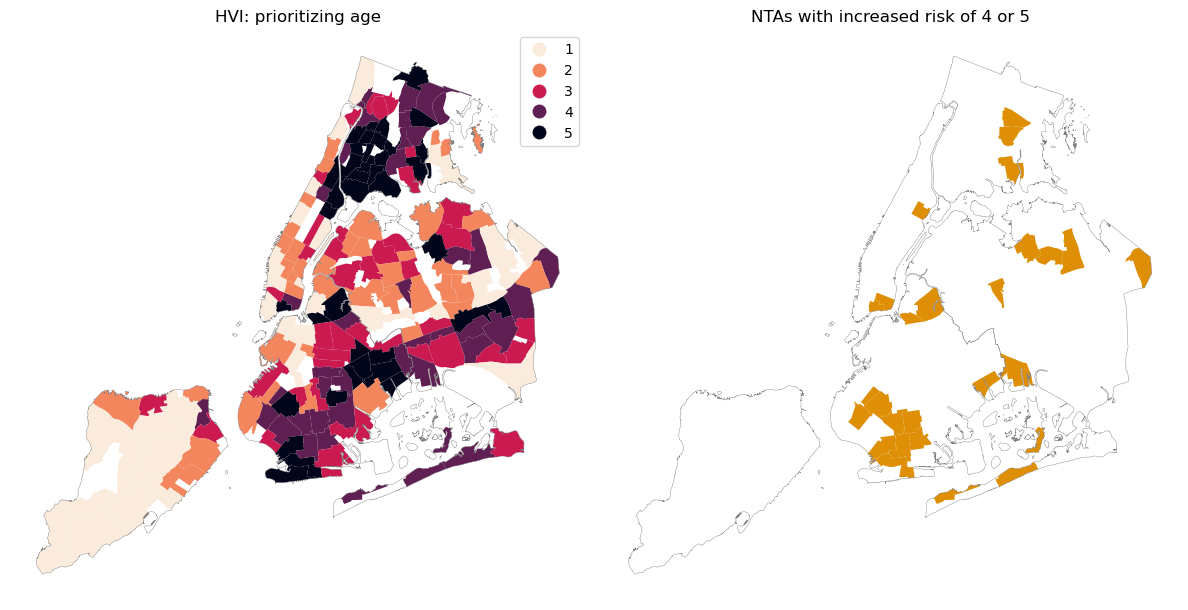

66                            West Farms
55                           Hunts Point
37                        Brighton Beach
67                               Tremont
36                 Coney Island-Sea Gate
59                     Crotona Park East
58    Claremont Village-Claremont (East)
45                           Brownsville
53                Mott Haven-Port Morris
57                            Morrisania
Name: ntaname, dtype: str


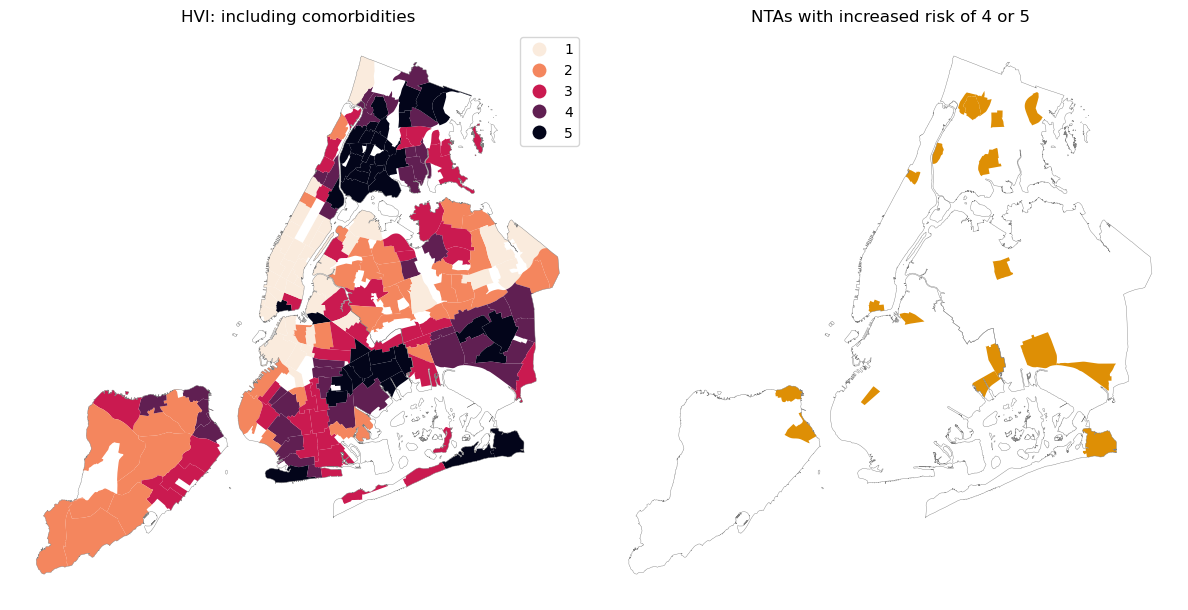

58           Claremont Village-Claremont (East)
66                                   West Farms
45                                  Brownsville
53                       Mott Haven-Port Morris
67                                      Tremont
57                                   Morrisania
54                                      Melrose
15                   Spring Creek-Starrett City
59                            Crotona Park East
63    University Heights (South)-Morris Heights
Name: ntaname, dtype: str


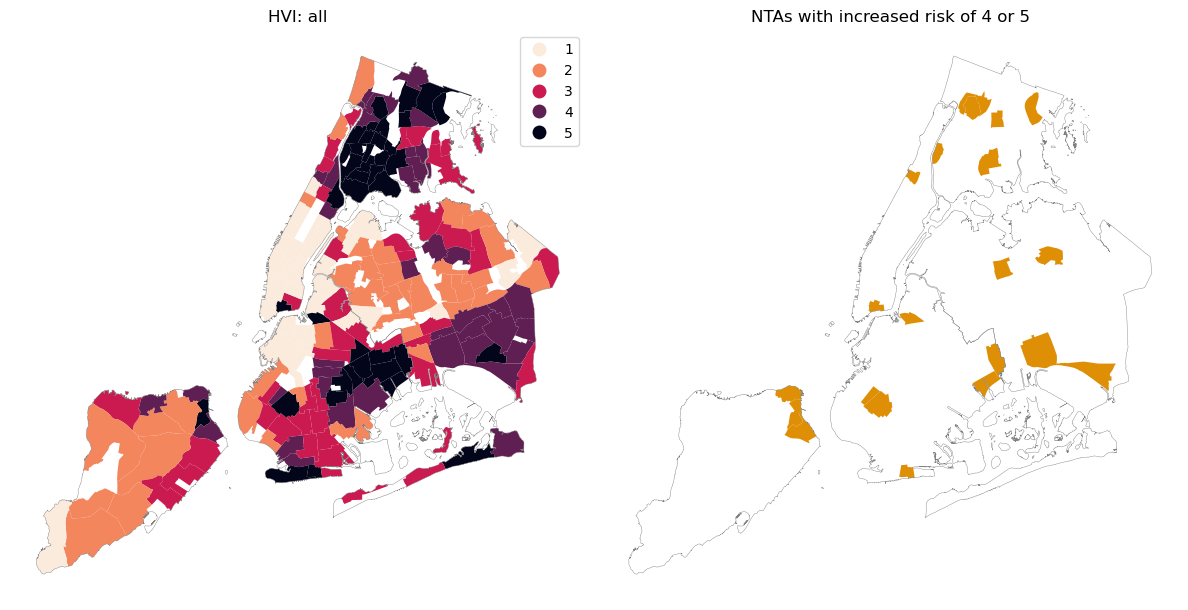

58    Claremont Village-Claremont (East)
66                            West Farms
45                           Brownsville
53                Mott Haven-Port Morris
15            Spring Creek-Starrett City
67                               Tremont
54                               Melrose
36                 Coney Island-Sea Gate
57                            Morrisania
59                     Crotona Park East
Name: ntaname, dtype: str


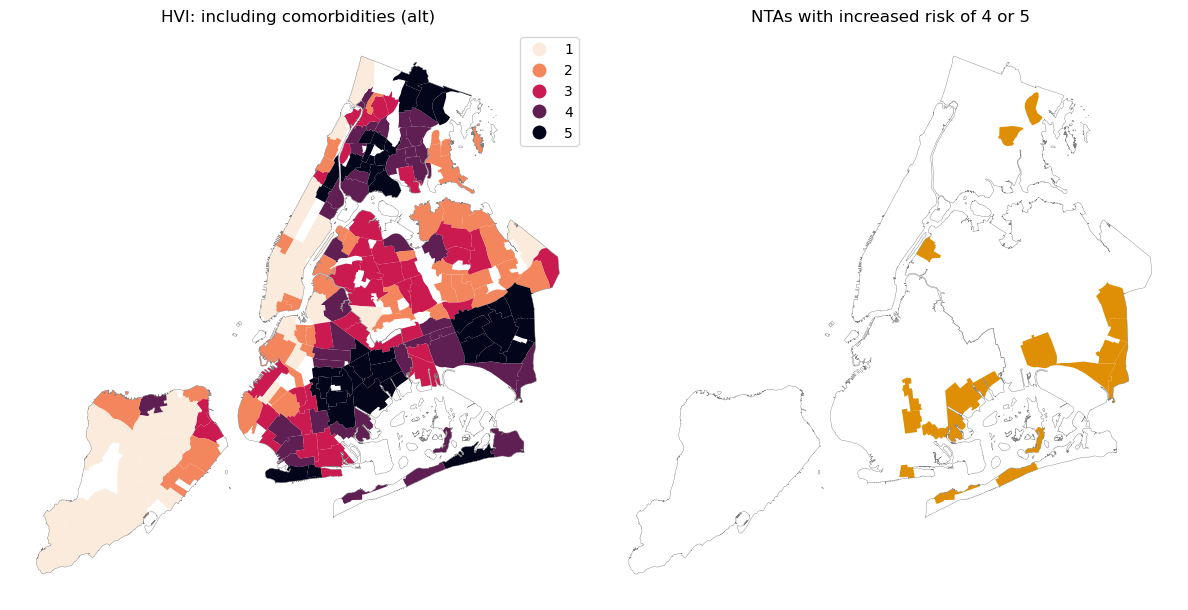

47                           East Flatbush-Farragut
48                              East Flatbush-Rugby
14                           East New York-New Lots
49                     East Flatbush-Remsen Village
169                                      St. Albans
45                                      Brownsville
168    Springfield Gardens (North)-Rochdale Village
59                                Crotona Park East
67                                          Tremont
44                                       Ocean Hill
Name: ntaname, dtype: str


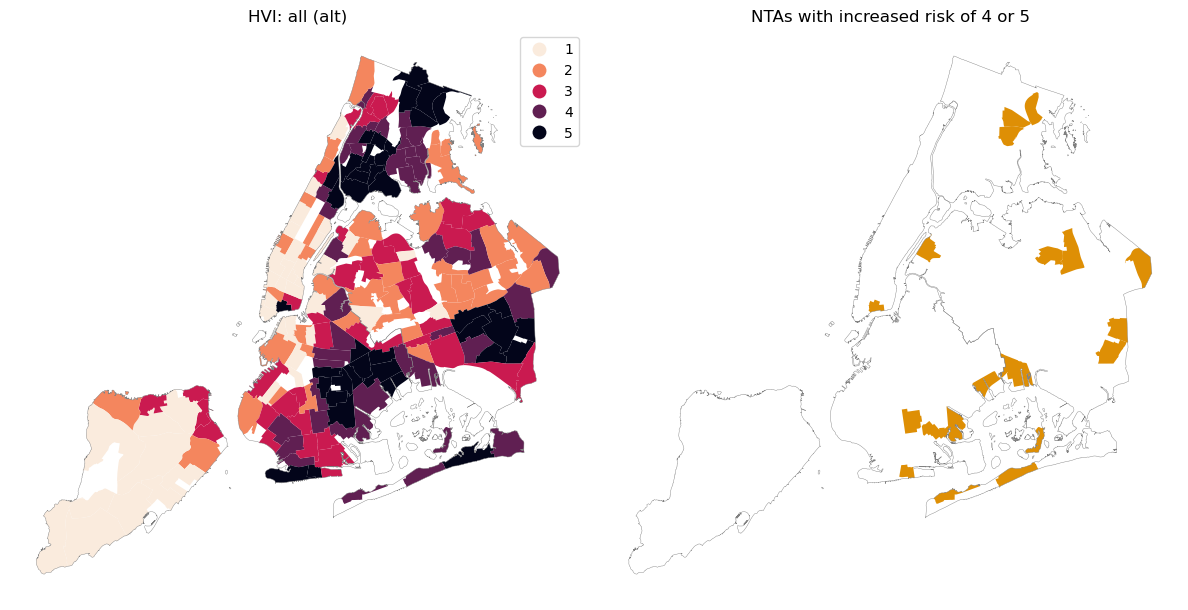

15      Spring Creek-Starrett City
45                     Brownsville
36           Coney Island-Sea Gate
14          East New York-New Lots
47          East Flatbush-Farragut
37                  Brighton Beach
49    East Flatbush-Remsen Village
48             East Flatbush-Rugby
67                         Tremont
66                      West Farms
Name: ntaname, dtype: str


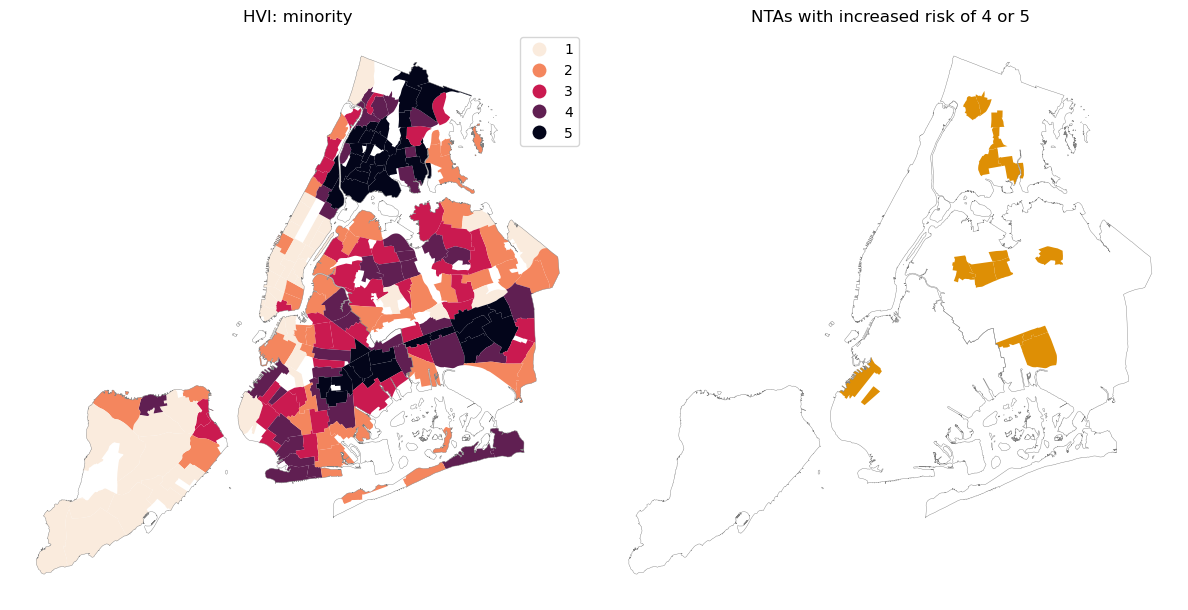

55                            Hunts Point
59                      Crotona Park East
67                                Tremont
58     Claremont Village-Claremont (East)
66                             West Farms
57                             Morrisania
64                             Mount Hope
53                 Mott Haven-Port Morris
165                               Jamaica
68                                Belmont
Name: ntaname, dtype: str


In [51]:
titles = [
    "HVI: environmental only",
    "HVI: prioritizing age",
    "HVI: including comorbidities",
    "HVI: all",
    "HVI: including comorbidities (alt)",
    "HVI: all (alt)",
    "HVI: minority",
]

produce_risk_increase_map(gdf_alt_increases, alt_specifications, boros_geo, titles)

## Produce NYC HVI at the census tract level

In [52]:
# produce NTA version with similar inputs that match (e.g., LST and % vegetation)
df_hvi_nta_tractrepl = (
    standardize_values(
        df_mgd_nta,
        [
            "_mean_f",
            "pct_vegetation",
            "PCT_BLACK_POP",
            "MEDIAN_INCOME",
            "PCT_HOUSEHOLDS_AC",
        ],
        rank_method,
    )
    .copy()
    .merge(
        gdf_alt_specifications[["nta2020", "HVI_raw_rank", "HVI_raw_q5"]],
        on="nta2020",
        how="left",
    )
)

print(f"Data size after merging: {df_hvi_nta_tractrepl.shape[0]}")

df_hvi_nta_tractrepl["HVI_nta_repl"] = produce_hvi_alternatives(
    df_hvi_nta_tractrepl,
    ["_mean_f_z", "PCT_BLACK_POP_z"],
    ["pct_vegetation_z", "PCT_HOUSEHOLDS_AC_z", "MEDIAN_INCOME_z"],
)

df_hvi_nta_tractrepl["HVI_nta_repl_rank"], df_hvi_nta_tractrepl["HVI_nta_repl_q5"] = (
    custom_qcut_function(df_hvi_nta_tractrepl["HVI_nta_repl"], method=rank_method)
)

Data size after merging: 197


In [53]:
df_hvi_nta_tractrepl[["pct_vegetation", "GREENSPACE"]].corr(method=correlation_method)

,pct_vegetation,GREENSPACE
pct_vegetation,1.00000,0.99997
GREENSPACE,0.99997,1.00000


In [54]:
# comparing the replicated NTA version to the original
print(
    f"Overall alignment: {100*(df_hvi_nta_tractrepl["HVI_nta_repl_q5"] == df_hvi_nta_tractrepl["HVI_raw_q5"]).mean().round(3)}"
)
df_hvi_nta_tractrepl[["HVI_nta_repl_rank", "HVI_raw_rank"]].corr(
    method=correlation_method
)

Overall alignment: 93.89999999999999


,HVI_nta_repl_rank,HVI_raw_rank
HVI_nta_repl_rank,1.000000,0.998344
HVI_raw_rank,0.998344,1.000000


In [55]:
df_hvi_nta_tractrepl[
    df_hvi_nta_tractrepl["HVI_nta_repl_q5"] != df_hvi_nta_tractrepl["HVI_raw_q5"]
][["SURFACE_TEMP", "_mean_f"]]

,SURFACE_TEMP,_mean_f
19,83.948,84.840037
23,87.278,88.243448
76,86.846,87.460794
113,84.740,86.299127
123,85.856,87.183456
126,86.972,88.364785
127,87.404,89.372960
130,86.864,88.257837
147,87.998,89.734239
154,88.970,89.532522


In [56]:
df_tract_hvi = merge_tract_nta(df_hvi_nta_tractrepl, df_mgd)

Data shape: (2292, 9)
After dropping missing AC values, data shape is: (2240, 9)


In [57]:
# produce NTA version with similar inputs that match (e.g., LST and % vegetation)
df_tract_hvi_alt_spec = standardize_values(
    df_tract_hvi,
    ["_mean_f", "pct_vegetation", "pct_black", "median_hhinc", "PCT_HOUSEHOLDS_AC"],
    rank_method,
).copy()

df_tract_hvi_alt_spec["HVI_tract"] = produce_hvi_alternatives(
    df_tract_hvi_alt_spec,
    ["_mean_f_z", "pct_black_z"],
    ["pct_vegetation_z", "PCT_HOUSEHOLDS_AC_z", "median_hhinc_z"],
)

df_tract_hvi_alt_spec["HVI_tract_rank"], df_tract_hvi_alt_spec["HVI_tract_q5"] = (
    custom_qcut_function(df_tract_hvi_alt_spec["HVI_tract"], method=rank_method)
)

In [58]:
# merge on NTA-level data
gdf_tract_hvi = (
    tract_geo[["geoid", "geometry"]]
    .merge(df_tract_hvi_alt_spec, on="geoid", how="inner")
    .merge(
        gdf_alt_specifications[["nta2020", "HVI_raw_rank", "HVI_raw_q5"]],
        on="nta2020",
        how="left",
    )
    .merge(
        df_hvi_nta_tractrepl[
            [
                "nta2020",
                "HVI_nta_repl",
                "HVI_nta_repl_rank",
                "HVI_nta_repl_q5",
            ]
        ].drop_duplicates(),
        how="left",
        on="nta2020",
        suffixes=("", "_nta"),
    )
    .merge(df_nri, on="geoid", how="left")
)

In [59]:
gdf_tract_hvi[
    [
        "HVI_nta_repl_rank",
        "HVI_tract_rank",
        "HVI_raw_rank",
        "HVI_nta_repl_q5",
        "HVI_tract_q5",
    ]
    + [
        "HWAV_EALT_rank",
        "HWAV_EALTxSVIxRESL_rank",
        "HWAV_EALT_NatlPct",
        "HWAV_Score",
        "HWAV_Rating",
    ]
].corr(method=correlation_method)

,HVI_nta_repl_rank,HVI_tract_rank,HVI_raw_rank,HVI_nta_repl_q5,HVI_tract_q5,HWAV_EALT_rank,HWAV_EALTxSVIxRESL_rank,HWAV_EALT_NatlPct,HWAV_Score,HWAV_Rating
HVI_nta_repl_rank,1.000000,0.891177,0.998254,0.978873,0.873765,-0.088224,0.070969,-0.361769,0.070969,0.077088
HVI_tract_rank,0.891177,1.000000,0.890259,0.870825,0.979796,-0.059819,0.105916,-0.337270,0.105916,0.109437
HVI_raw_rank,0.998254,0.890259,1.000000,0.976320,0.872989,-0.089792,0.070079,-0.362463,0.070079,0.077011
HVI_nta_repl_q5,0.978873,0.870825,0.976320,1.000000,0.858245,-0.085468,0.071435,-0.356652,0.071435,0.076473
HVI_tract_q5,0.873765,0.979796,0.872989,0.858245,1.000000,-0.057147,0.106249,-0.333670,0.106249,0.108507
HWAV_EALT_rank,-0.088224,-0.059819,-0.089792,-0.085468,-0.057147,1.000000,0.924343,-0.298069,0.924343,0.818262
HWAV_EALTxSVIxRESL_rank,0.070969,0.105916,0.070079,0.071435,0.106249,0.924343,1.000000,-0.400580,1.000000,0.896899
HWAV_EALT_NatlPct,-0.361769,-0.337270,-0.362463,-0.356652,-0.333670,-0.298069,-0.400580,1.000000,-0.400580,-0.362472
HWAV_Score,0.070969,0.105916,0.070079,0.071435,0.106249,0.924343,1.000000,-0.400580,1.000000,0.896899
HWAV_Rating,0.077088,0.109437,0.077011,0.076473,0.108507,0.818262,0.896899,-0.362472,0.896899,1.000000


In [60]:
gdf_tract_hvi_summary = gdf_tract_hvi.groupby(["HVI_nta_repl_rank"], as_index=False)[
    "HVI_tract_rank"
].agg(["max", "min", "mean", "std"])
gdf_tract_hvi_summary

,HVI_nta_repl_rank,max,min,mean,std
0,0.507614,22.500000,0.044643,8.938492,9.025914
1,1.015228,16.875000,0.089286,3.584184,5.959819
2,1.522843,5.267857,0.758929,3.013393,3.188294
3,2.030457,10.625000,1.339286,5.714286,4.351553
4,2.538071,16.607143,0.267857,6.422194,5.965764
...,...,...,...,...,...
192,97.969543,99.866071,89.553571,95.258929,4.403764
193,98.477157,99.419643,96.651786,98.482143,0.845567
194,98.984772,99.642857,85.982143,96.932398,3.925074
195,99.492386,99.910714,96.071429,98.105867,1.475885


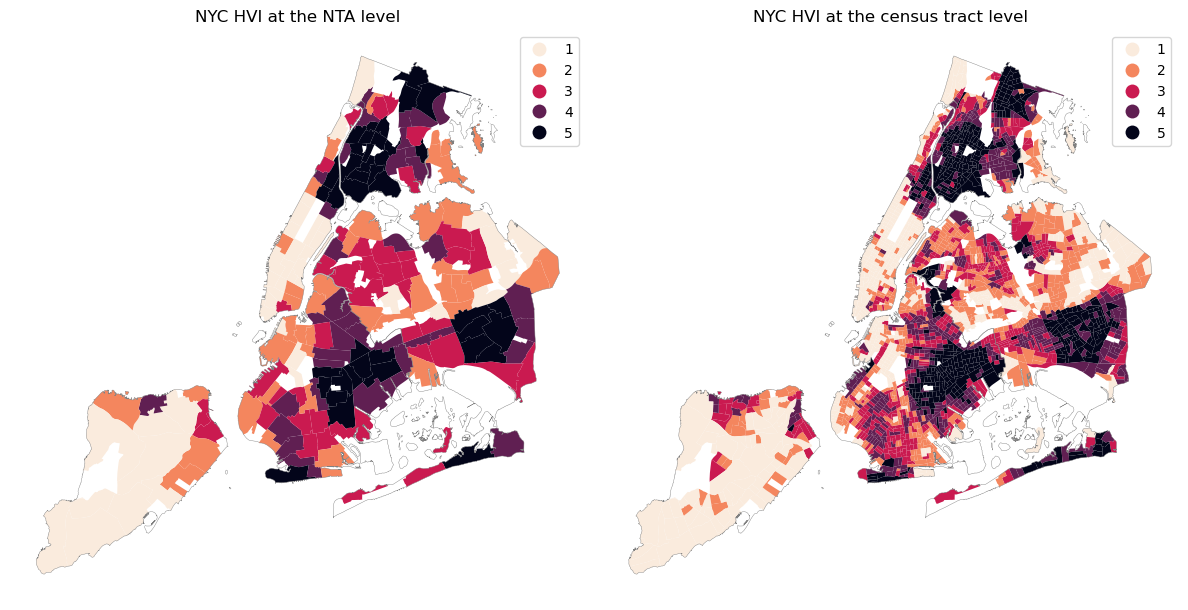

In [61]:
def nta_tract_comparison_map(gdf, tract_gdf, nyc_boros):
    """Produce NTA vs. Census tract map"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    gdf["HVI_nta_repl_q5"] = gdf["HVI_nta_repl_q5"].astype(str).str.replace(".0", "")
    tract_gdf["HVI_tract_q5"] = (
        tract_gdf["HVI_tract_q5"].astype(str).str.replace(".0", "")
    )
    gdf.plot(
        column="HVI_nta_repl_q5",
        ax=axes[0],
        cmap="rocket_r",
        legend=True,
        edgecolor="none",
    )
    tract_gdf.plot(
        column="HVI_tract_q5",
        cmap="rocket_r",
        ax=axes[1],
        legend=True,
        edgecolor="none",
    )
    axes[0].set_axis_off()
    axes[1].set_axis_off()

    axes[0].set_title("NYC HVI at the NTA level")
    axes[1].set_title("NYC HVI at the census tract level")
    nyc_boros.plot(ax=axes[0], facecolor="none", edgecolor="gray", lw=0.3)
    nyc_boros.plot(ax=axes[1], facecolor="none", edgecolor="gray", lw=0.3)

    plt.savefig(
        "_figures/heat_vulnerability_nta_vs_census_tract.pdf",
        bbox_inches="tight",
        pad_inches=0,
        dpi=300,
    )
    plt.tight_layout()
    plt.show()


nta_tract_comparison_map(
    nta_geo.merge(df_hvi_nta_tractrepl[["nta2020", "HVI_nta_repl_q5"]]),
    gdf_tract_hvi,
    boros_geo,
)

## Prep data for scatter plots / alternative specifications visualization

In [62]:
# tract level
gdf_tract_hvi["HVI_tract_q5"] = gdf_tract_hvi["HVI_tract_q5"].astype(int)
gdf_tract_hvi_plt = prep_for_plot(gdf_tract_hvi, ["HVI_tract"], "HVI_nta_repl", "geoid")
gdf_tract_hvi_plt.head()

------------------------
Prepping data for plotting
id var: geoid
vars to pivot: HVI_tract
Data size: (2240, 506)


,geoid,rank,q5,variable,HVI_nta_repl_rank,HVI_nta_repl_q5,color,label
0,36061002201,42.142857,3,HVI_tract,36.548223,2.0,#029e73,Increased HVI score
1,36061002602,25.000000,2,HVI_tract,30.456853,2.0,gray,Unchanged HVI score
2,36061002800,42.366071,3,HVI_tract,30.456853,2.0,#029e73,Increased HVI score
3,36061003400,26.562500,2,HVI_tract,30.456853,2.0,gray,Unchanged HVI score
4,36061003601,37.455357,2,HVI_tract,36.548223,2.0,gray,Unchanged HVI score


In [63]:
# NTA level
gdf_nta_hvi_plt = prep_for_plot(
    gdf_alt_specifications,
    ["HVI_env", "HVI_age", "HVI_health", "HVI_all"],
    "HVI_raw",
    "nta2020",
)
gdf_nta_hvi_plt.head()

------------------------
Prepping data for plotting
id var: nta2020
vars to pivot: HVI_env, HVI_age, HVI_health, HVI_all
Data size: (197, 82)


,nta2020,rank,q5,variable,HVI_raw_rank,HVI_raw_q5,color,label
0,BK0101,72.588832,4.0,HVI_env,36.548223,2.0,#029e73,Increased HVI score
1,BK0102,47.715736,3.0,HVI_env,24.365482,2.0,#029e73,Increased HVI score
2,BK0103,79.695431,4.0,HVI_env,66.497462,4.0,gray,Unchanged HVI score
3,BK0104,97.969543,5.0,HVI_env,73.096447,4.0,#029e73,Increased HVI score
4,BK0201,6.598985,1.0,HVI_env,5.076142,1.0,gray,Unchanged HVI score


In [64]:
gdf_nta_hvi_plt["label"].value_counts(normalize=True)

label
Unchanged HVI score    0.475888
Increased HVI score    0.262690
Decreased HVI score    0.261421
Name: proportion, dtype: float64

In [65]:
gdf_nta_hvi_plt["exp_nochange"] = gdf_nta_hvi_plt["label"] == "Unchanged HVI score"
pct_ntas_with_no_change = (
    gdf_nta_hvi_plt.groupby("nta2020")["exp_nochange"].all().mean()
)
print(
    f"{str((100*pct_ntas_with_no_change).round(1))}% of NTAs would not experience any change across all specifications"
)

12.2% of NTAs would not experience any change across all specifications


In [66]:
gdf_nta_hvi_plt[
    (gdf_nta_hvi_plt["label"] == "Increased HVI score")
    & (gdf_nta_hvi_plt["HVI_raw_q5"].isin([1, 2]))
    & (gdf_nta_hvi_plt["q5"].isin([4, 5]))
]["nta2020"].unique().shape[0]

9

## Prep NRI data for scatter plots

In [67]:
gdf_nri_plt = prep_for_plot(
    gdf_tract_hvi, ["HWAV_EALTxSVIxRESL", "HWAV_EALT"], "HVI_raw", "geoid"
)

------------------------
Prepping data for plotting
id var: geoid
vars to pivot: HWAV_EALTxSVIxRESL, HWAV_EALT
Data size: (2240, 506)


In [68]:
gdf_nri_plt["label"].value_counts(normalize=True)

label
Decreased HVI score    0.420536
Increased HVI score    0.377902
Unchanged HVI score    0.201563
Name: proportion, dtype: float64

In [69]:
min_max_summary(
    gdf_tract_hvi,
    [
        "geoid",
        "HVI_raw_rank",
        "HVI_nta_repl_rank",
        "HVI_tract_rank",
    ],
    [
        "HWAV_EALTxSVIxRESL_rank",
        "HWAV_EALT_rank",
    ],
)[["min", "max", "mean", "std"]].mean()

min     47.620885
max     55.971270
mean    51.796078
std      5.904614
dtype: float64

In [70]:
def patches(ax, colorblind_cmap):
    decrease_patch = mpl.lines.Line2D(
        [0],
        [0],
        marker="s",
        markerfacecolor=colorblind_cmap[1],
        markersize=10,
        markeredgecolor="none",
        ls="",
        label="Decreased score",
    )
    increase_patch = mpl.lines.Line2D(
        [0],
        [0],
        marker="o",
        markerfacecolor=colorblind_cmap[2],
        markersize=10,
        markeredgecolor="none",
        ls="",
        label="Increased score",
    )
    nochange_patch = mpl.lines.Line2D(
        [0],
        [0],
        marker="X",
        markerfacecolor="gray",
        ls="",
        markersize=10,
        markeredgecolor="none",
        label="Unchanged score",
    )
    ax.legend(
        handles=[increase_patch, nochange_patch, decrease_patch],
        loc="lower right",
        fontsize=10,
    )

------------------------
Producing main facet plot (fig. 2)
Plotting HVI_env
df temp size: (197, 9)
Plotting HVI_age
df temp size: (197, 9)
Plotting HVI_health
df temp size: (197, 9)
Plotting HVI_all
df temp size: (197, 9)
Plotting HVI_tract
df temp size: (2240, 8)
Plotting HWAV_EALTxSVIxRESL
df temp size: (2240, 8)
Plotting HWAV_EALT
df temp size: (2240, 8)


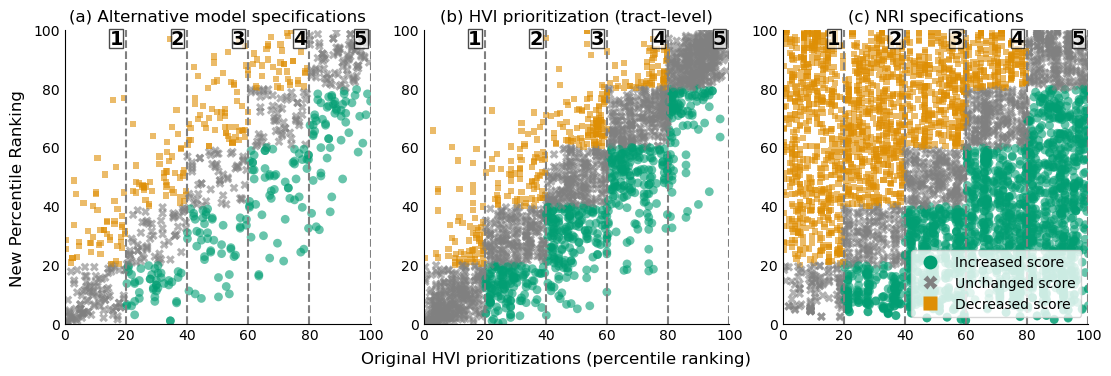

In [71]:
def produce_facet_plot(df_hvi, df_tract_hvi, df_nri, id_vars, filename):
    """Produces main facet plot"""
    print("------------------------")
    print("Producing main facet plot (fig. 2)")
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.65), layout="constrained")

    for i, ax in enumerate(axes):
        ax.axvline(20, color="gray", linestyle="dashed")
        ax.axvline(40, color="gray", linestyle="dashed")
        ax.axvline(60, color="gray", linestyle="dashed")
        ax.axvline(80, color="gray", linestyle="dashed")
        ax.axvline(100, color="gray", linestyle="dashed")

        if i == 0:
            produce_scatter(df_hvi, id_vars[i], ax)
            ax.set_title("(a) Alternative model specifications")
        elif i == 1:
            produce_scatter(df_tract_hvi, id_vars[i], ax)
            ax.set_title("(b) HVI prioritization (tract-level)")
        elif i == 2:
            produce_scatter(df_nri, id_vars[2], ax)
            ax.set_title("(c) NRI specifications")
        default_plot(ax)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xlim((0, 100))
        ax.set_ylim((0, 100))

        ax.text(
            19,
            95,
            "1",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            39,
            95,
            "2",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            59,
            95,
            "3",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            79,
            95,
            "4",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
        ax.text(
            99,
            95,
            "5",
            horizontalalignment="right",
            color="black",
            fontweight="bold",
            fontsize=14,
            bbox=dict(facecolor="white", pad=0, alpha=0.7),
        )
    patches(ax, colorblind_cmap)
    fig.supylabel("New Percentile Ranking")
    fig.supxlabel("Original HVI prioritizations (percentile ranking)")

    plt.savefig(f"./_figures/{filename}", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()


produce_facet_plot(
    gdf_nta_hvi_plt,
    gdf_tract_hvi_plt,
    gdf_nri_plt,
    ["HVI_raw", "HVI_nta_repl", "HVI_raw"],
    "lineplots_faceted.pdf",
)

## Compare HHI and HVI

In [72]:
zcta_nta_xwalk = tract_spatial_join(
    zcta_2010_geo,
    nta_geo.rename(columns={"nta2020": "geoid"}),
    spatial_join_method,
    "zcta",
).rename(columns={"geoid": "nta2020"})
hhi_hvi_comparison = (
    gdf_alt_specifications[["nta2020", "HVI_raw_rank", "HVI_raw_q5"]]
    .merge(zcta_nta_xwalk, on="nta2020")
    .merge(df_cdc_hhi_geo, on="zcta")
)
hhi_hvi_comparison[["HVI_raw_q5", "OVERALL_SCORE_q5"]] = hhi_hvi_comparison[
    ["HVI_raw_q5", "OVERALL_SCORE_q5"]
].astype(int)

print(f"Data size: {hhi_hvi_comparison.shape[0]}")

Tract CRS: EPSG:2263
ZCTA CRS: EPSG:2263
Merged data size: (260, 12)
Tract data size: (262, 12)
ZCTA/DPS data size: (213, 12)
Data size: 197


/opt/anaconda3/envs/index-env/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


In [73]:
hhi_hvi_comparison[f"color"] = np.select(
    [
        hhi_hvi_comparison["HVI_raw_q5"] < hhi_hvi_comparison[f"OVERALL_SCORE_q5"],
        hhi_hvi_comparison["HVI_raw_q5"] > hhi_hvi_comparison[f"OVERALL_SCORE_q5"],
    ],
    [colorblind_cmap[2], colorblind_cmap[1]],
    "#808080",
)

hhi_hvi_comparison[f"marker"] = np.select(
    [
        hhi_hvi_comparison["HVI_raw_q5"] < hhi_hvi_comparison[f"OVERALL_SCORE_q5"],
        hhi_hvi_comparison["HVI_raw_q5"] > hhi_hvi_comparison[f"OVERALL_SCORE_q5"],
    ],
    [markers[0], markers[1]],
    markers[2],
)

hhi_hvi_comparison["label"] = np.select(
    [
        hhi_hvi_comparison["color"] == colorblind_cmap[1],
        hhi_hvi_comparison["color"] == colorblind_cmap[2],
    ],
    ["Increased score", "Decreased score"],
    "Unchanged score",
)

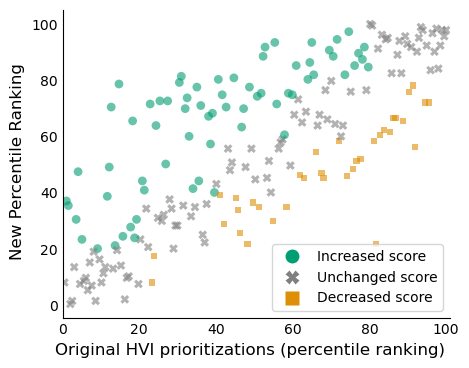

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.scatterplot(
    x=hhi_hvi_comparison["HVI_raw_rank"],
    y=hhi_hvi_comparison["OVERALL_SCORE_rank"],
    hue=hhi_hvi_comparison["label"],
    hue_order=["Decreased score", "Unchanged score", "Increased score"],
    style_order=[
        "Decreased score",
        "Unchanged score",
        "Increased score",
    ],
    palette=[colorblind_cmap[2], "#808080", colorblind_cmap[1]],
    style=hhi_hvi_comparison["label"],
    markers=True,
    legend=False,
    s=40,
    alpha=0.6,
    linewidth=0,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")

fig.supylabel("New Percentile Ranking")
fig.supxlabel("Original HVI prioritizations (percentile ranking)")

patches(ax, colorblind_cmap)
plt.xlim(0, 101)

default_plot(ax)
plt.savefig("_figures/hhi_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show();

## Compare to heat-related impacts

In [80]:
gdf_311_summ = load_311(tract_geo, load_impacts=load_impacts)
gdf_311_summ = create_311_grid(gdf_311_summ, tract_geo, dec_gdf)
gdf_311_summ.sort_values("count_pp_hydrant", ascending=False).head()

------------------------
Loading 311 hydrant data via API


,geoid,count_pp_hydrant,count_pp_hydrant_rank,count_pp_hydrant_q5
6,36005001903,122.317597,100.00000,5.0
1732,36081038301,45.064378,99.95637,5.0
1453,36061031100,21.459227,99.91274,5.0
185,36005024900,17.167382,99.82548,5.0
333,36005043502,17.167382,99.82548,5.0


In [81]:
df_ems_summ = load_ems(load_impacts=load_impacts)
df_ems_summ = create_ems_grid(df_ems_summ, zcta_geo)

# crosswalk with tract data
zcta_tract_xwalk = tract_spatial_join(
    zcta_geo, tract_geo, method=spatial_join_method, spatial_id="zcta"
)
df_ems_tract_summ = df_ems_summ.merge(zcta_tract_xwalk[["zcta", "geoid"]], on="zcta")
df_ems_tract_summ.sort_values("count", ascending=False).head()

------------------------
Loading EMS data via API
Tract CRS: EPSG:2263
ZCTA CRS: EPSG:2263
Merged data size: (2322, 10)
Tract data size: (2325, 14)
ZCTA/DPS data size: (214, 10)


/opt/anaconda3/envs/index-env/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


,zcta,count,ems_count_rank,ems_count_q5,geoid
247,10035,0.424779,100.0,5.0,36061024000
248,10035,0.424779,100.0,5.0,36061020600
249,10035,0.424779,100.0,5.0,36061019800
250,10035,0.424779,100.0,5.0,36061019600
251,10035,0.424779,100.0,5.0,36061019400


In [99]:
# produce xwalk for dps locality service areas to tracts
dps_geo = gpd.read_file("_data/_foil/e_locality/e_locality.shp").to_crs(2263)
dps_tract_xwalk = tract_spatial_join(
    dps_geo, tract_geo, method="spatial_overlap", spatial_id="PRIME_DPS_"
)
df_dps_tract_summ = clean_dps(dps_geo, dps_tract_xwalk)

Tract CRS: EPSG:2263
ZCTA CRS: EPSG:2263


/opt/anaconda3/envs/index-env/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


Merged data size: (2322, 14)
Tract data size: (2325, 14)
ZCTA/DPS data size: (1865, 14)
------------------------
Loading DPS Data on Power Outages


/Users/jennah/code/ScrutinizingIndexRiskAssessments/scripts/heat_impacts_preprocessing.py:234: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_dps["SUBMIT_DATETIME"] = pd.to_datetime(


Unique values of DPS_ORDER var: <ArrowStringArray>
['0', '2']
Length: 2, dtype: str
Dataset size prior to xwalk with census tracts: 78
Dataset size after merging with census tracts: 2322


In [100]:
df_impacts_compare = (
    gdf_tract_hvi.merge(df_cdc_hhi_tract, on="geoid", how="left")
    .merge(gdf_311_summ, on="geoid", how="left")
    .merge(df_ems_tract_summ, on="geoid", how="left")
    .merge(df_dps_tract_summ, on="geoid", how="left")
)
print(f"Dataset size: {df_impacts_compare.shape[0]}")
produce_correlations(
    df_impacts_compare,
    [
        "HVI_raw_rank",
        "HVI_nta_repl_rank",
        "HVI_tract_rank",
        "HWAV_EALTxSVIxRESL_rank",
        "OVERALL_RANK",
        "CUSTOMERS_OUT_RATE_rank",
        "ems_count_rank",
        "count_pp_hydrant_rank",
    ],
    correlation_method,
)

Dataset size: 2240
------------------------
Correlation using spearman
\begin{tabular}{lllllllll}
\toprule
 & HVI_raw_rank & HVI_nta_repl_rank & HVI_tract_rank & HWAV_EALTxSVIxRESL_rank & OVERALL_RANK & CUSTOMERS_OUT_RATE_rank & ems_count_rank & count_pp_hydrant_rank \\
\midrule
HVI_raw_rank & 1.0 & 0.998 & 0.89 & 0.07 & 0.693 & 0.167 & 0.181 & 0.307 \\
HVI_nta_repl_rank & 0.998 & 1.0 & 0.891 & 0.071 & 0.692 & 0.156 & 0.186 & 0.306 \\
HVI_tract_rank & 0.89 & 0.891 & 1.0 & 0.106 & 0.65 & 0.14 & 0.19 & 0.354 \\
HWAV_EALTxSVIxRESL_rank & 0.07 & 0.071 & 0.106 & 1.0 & 0.289 & -0.178 & 0.258 & 0.086 \\
OVERALL_RANK & 0.693 & 0.692 & 0.65 & 0.289 & 1.0 & 0.037 & 0.351 & 0.398 \\
CUSTOMERS_OUT_RATE_rank & 0.167 & 0.156 & 0.14 & -0.178 & 0.037 & 1.0 & -0.335 & -0.015 \\
ems_count_rank & 0.181 & 0.186 & 0.19 & 0.258 & 0.351 & -0.335 & 1.0 & 0.278 \\
count_pp_hydrant_rank & 0.307 & 0.306 & 0.354 & 0.086 & 0.398 & -0.015 & 0.278 & 1.0 \\
\bottomrule
\end{tabular}



,HVI_raw_rank,HVI_nta_repl_rank,HVI_tract_rank,HWAV_EALTxSVIxRESL_rank,OVERALL_RANK,CUSTOMERS_OUT_RATE_rank,ems_count_rank,count_pp_hydrant_rank
HVI_raw_rank,1.000000,0.998254,0.890259,0.070079,0.692819,0.166864,0.181285,0.307213
HVI_nta_repl_rank,0.998254,1.000000,0.891177,0.070969,0.691802,0.155513,0.185671,0.306338
HVI_tract_rank,0.890259,0.891177,1.000000,0.105916,0.649824,0.140181,0.190179,0.353906
HWAV_EALTxSVIxRESL_rank,0.070079,0.070969,0.105916,1.000000,0.289322,-0.178056,0.257523,0.086456
OVERALL_RANK,0.692819,0.691802,0.649824,0.289322,1.000000,0.036769,0.351125,0.398394
CUSTOMERS_OUT_RATE_rank,0.166864,0.155513,0.140181,-0.178056,0.036769,1.000000,-0.335299,-0.015459
ems_count_rank,0.181285,0.185671,0.190179,0.257523,0.351125,-0.335299,1.000000,0.278094
count_pp_hydrant_rank,0.307213,0.306338,0.353906,0.086456,0.398394,-0.015459,0.278094,1.000000


### Validate spatial join method

In [105]:
check_census_relfile_matches(nyc_counties, zcta_geo, tract_geo)

Number of unique ZCTAs 215
Tract CRS: EPSG:2263
ZCTA CRS: EPSG:2263
Merged data size: (2322, 10)
Tract data size: (2325, 14)
ZCTA/DPS data size: (214, 10)

% incorrect assignments: 0.0%
Number of rows in rel file: 2318


/opt/anaconda3/envs/index-env/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


## Comparison of HHI, HVI, and EMS Calls using NYC Zip Code Tabulation Area

In [106]:
rel_file = pd.read_csv(
    "https://www2.census.gov/geo/docs/maps-data/data/rel2020/zcta520/tab20_zcta510_zcta520_natl.txt",
    sep="|",
)
rel_file = rel_file.rename(
    columns={"GEOID_ZCTA5_10": "zcta_2010", "GEOID_ZCTA5_20": "zcta"}
)
rel_file = rel_file.sort_values("AREALAND_PART", ascending=False).drop_duplicates(
    subset="zcta", keep="first"
)
rel_file["zcta"] = rel_file["zcta"].astype(str).str.replace(".0", "")
rel_file["zcta_2010"] = rel_file["zcta_2010"].astype(str).str.replace(".0", "")
df_zcta_comparison = (
    df_hvi_zcta.merge(df_ems_summ, on="zcta", how="left")
    .merge(rel_file, on="zcta", how="left")
    .merge(df_cdc_hhi_geo, left_on="zcta_2010", right_on="zcta", how="left")
)

print(f"Data shape after merging: {df_zcta_comparison.shape[0]}")
print(
    f"Number of missing values: {df_zcta_comparison[['hvi', 'ems_count_q5', 'OVERALL_SCORE_q5']].isna().sum()}"
)
produce_correlations(
    df_zcta_comparison, ["hvi", "OVERALL_SCORE_q5", "ems_count_q5"], correlation_method
)

Data shape after merging: 184
Number of missing values: hvi                 0
ems_count_q5        0
OVERALL_SCORE_q5    3
dtype: int64
------------------------
Correlation using spearman
\begin{tabular}{llll}
\toprule
 & hvi & OVERALL_SCORE_q5 & ems_count_q5 \\
\midrule
hvi & 1.0 & 0.744 & 0.249 \\
OVERALL_SCORE_q5 & 0.744 & 1.0 & 0.278 \\
ems_count_q5 & 0.249 & 0.278 & 1.0 \\
\bottomrule
\end{tabular}



,hvi,OVERALL_SCORE_q5,ems_count_q5
hvi,1.000000,0.743559,0.248982
OVERALL_SCORE_q5,0.743559,1.000000,0.277759
ems_count_q5,0.248982,0.277759,1.000000
